# Café Customer Analytics & Churn Prediction
### From transaction data to customer behavior, churn risk, and retention

**Portfolio Project**

I built this project using the café datasets from my Python Data Analysis & AI course. I wanted to practice the full analysis process, from cleaning the data to understanding customer behavior and building a churn model.

### Questions I wanted to answer
1. How did revenue, orders, and active customers change during 2025?
2. Which customers and product categories contributed most to performance?
3. Can customers be grouped based on their behavior?
4. Can I identify customers who are less likely to return?
5. How can churn risk and customer value be used together for retention?
6. What can the coupon pilot tell me about different discount levels?

### Main tools and methods
- Python, Pandas, NumPy
- Data cleaning and feature engineering
- Exploratory analysis and visualization
- Pareto analysis
- RFM-style customer segmentation
- K-Means and PCA
- Churn modeling with scikit-learn
- Cross-validation and held-out testing
- Logistic Regression, Decision Tree, Random Forest
- ROC-AUC, Precision, Recall, F1
- Permutation importance
- Customer risk prioritization
- Coupon pilot analysis

> **Project context:** This is my own organized implementation using course-provided educational datasets.

> **Colab note:** Use **Runtime → Run all**. The notebook saves the main figures to `MyDrive/Cafe_Customer_Analytics/images/`.


## Table of Contents

1. Environment & Data Loading  
2. Data Audit & Cleaning  
3. Business Performance Overview  
4. Trend Decomposition  
5. Customer Concentration & Pareto Analysis  
6. Product, Channel, Store & Time Analysis  
7. Customer Behavioral Profile  
8. Customer Segmentation with K-Means  
9. Churn Definition & Feature Engineering  
10. Machine Learning with Cross-Validation  
11. Held-Out Test Evaluation  
12. Churn Driver Interpretation  
13. Customer Risk Prioritization  
14. Coupon Pilot Analysis  
15. Recommended Actions  
16. Limitations & Next Steps  
17. Export Portfolio Outputs

## 1. Environment & Data Loading

In [1]:
# Core libraries
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    silhouette_score
)

from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_context('notebook')

In [2]:
# Mount Google Drive when running in Google Colab.
# If Drive is already mounted, Colab will simply reuse it.

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab.")

Mounted at /content/drive


In [3]:
# File locations
PROJECT_DIR = '/content/drive/MyDrive/Cafe_Customer_Analytics'
DATA_DIR = f'{PROJECT_DIR}/data'
OUTPUT_DIR = f'{PROJECT_DIR}/outputs'
IMAGE_DIR = f'{PROJECT_DIR}/images'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

ORDERS_PATH = f'{DATA_DIR}/cafe_orders.csv'
COUPON_PATH = f'{DATA_DIR}/coupon_pilot.csv'

# Load datasets
orders_raw = pd.read_csv(ORDERS_PATH)
coupon_raw = pd.read_csv(COUPON_PATH)

print("Orders dataset:", orders_raw.shape)
print("Coupon dataset:", coupon_raw.shape)

display(orders_raw.head())
display(coupon_raw.head())

Orders dataset: (81623, 14)
Coupon dataset: (6000, 4)


,order_id,order_received_at,user_id,gender,age,membership,order_source,is_reorder,store_type,order_type,category,item_temp,final_amount,discount_type
0,ORD_0072950,2025-01-01 07:01:29,USER_05361,F,20.000,Gold,Mobile_App,True,오피스,Eat-in,Coffee,Iced,5300,Membership
1,ORD_0053774,2025-01-01 07:03:32,USER_03954,M,46.000,Gold,POS,False,오피스,Delivery,Bakery,Iced,5290,Promotion
2,ORD_0064388,2025-01-01 07:05:14,USER_04733,F,32.000,Silver,Mobile_App,True,오피스,Eat-in,Bakery,Iced,5640,Membership
3,ORD_0064427,2025-01-01 07:05:32,USER_04737,F,NaN,Gold,Mobile_App,True,주거,Eat-in,Beverage,Hot,5520,Promotion
4,ORD_0057476,2025-01-01 07:06:20,USER_04224,M,54.000,Gold,Mobile_App,True,오피스,Delivery,Bakery,Hot,4730,Coupon


,user_id,pilot_group,coupon_amount,campaign_spend_30d
0,USER_00000,Coupon_2000,2000,11881
1,USER_00001,Coupon_2000,2000,12588
2,USER_00002,Coupon_1000,1000,8530
3,USER_00003,Coupon_2000,2000,15348
4,USER_00004,Control,0,16001


## 2. Data Audit & Cleaning

Before starting the analysis, I checked the data types, missing values, duplicates, transaction values, and date range.

I kept the original dataframe and created a separate cleaned copy for the analysis.


In [4]:
# Dataset structure
orders_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81623 entries, 0 to 81622
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           81623 non-null  object 
 1   order_received_at  81623 non-null  object 
 2   user_id            81623 non-null  object 
 3   gender             80720 non-null  object 
 4   age                79428 non-null  float64
 5   membership         69330 non-null  object 
 6   order_source       81623 non-null  object 
 7   is_reorder         81623 non-null  bool   
 8   store_type         81623 non-null  object 
 9   order_type         81623 non-null  object 
 10  category           81623 non-null  object 
 11  item_temp          81623 non-null  object 
 12  final_amount       81623 non-null  int64  
 13  discount_type      48430 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(11)
memory usage: 8.2+ MB


In [5]:
# Missing-value audit
missing_audit = pd.DataFrame({
    'missing_count': orders_raw.isna().sum(),
    'missing_pct': orders_raw.isna().mean() * 100
}).sort_values('missing_pct', ascending=False)

display(missing_audit)

,missing_count,missing_pct
discount_type,33193,40.666
membership,12293,15.061
age,2195,2.689
gender,903,1.106
order_received_at,0,0.000
order_id,0,0.000
user_id,0,0.000
order_source,0,0.000
store_type,0,0.000
is_reorder,0,0.000


In [6]:
# Data-quality checks
print("Duplicate rows:", orders_raw.duplicated().sum())
print("Duplicate order IDs:", orders_raw['order_id'].duplicated().sum())
print("Non-positive transaction amounts:", (orders_raw['final_amount'] <= 0).sum())

print("\nAge range:")
display(orders_raw['age'].describe())

Duplicate rows: 0
Duplicate order IDs: 0
Non-positive transaction amounts: 0

Age range:


,age
count,"79,428.000"
mean,34.566
std,11.224
min,18.000
25%,25.000
50%,34.000
75%,42.000
max,70.000


In [7]:
# Create a clean working copy
orders = orders_raw.copy()

# Convert time
orders['order_received_at'] = pd.to_datetime(
    orders['order_received_at'],
    errors='coerce'
)

# Missing categorical values with meaningful labels
orders['gender'] = orders['gender'].fillna('Unknown')
orders['membership'] = orders['membership'].fillna('Non-member')
orders['discount_type'] = orders['discount_type'].fillna('No Discount')

# Age remains missing here.
# It will be handled inside the ML preprocessing pipeline to avoid leakage.

# Time features
orders['date'] = orders['order_received_at'].dt.date
orders['month'] = orders['order_received_at'].dt.to_period('M').astype(str)
orders['month_num'] = orders['order_received_at'].dt.month
orders['day_of_week'] = orders['order_received_at'].dt.day_name()
orders['hour'] = orders['order_received_at'].dt.hour

print("Date range:", orders['order_received_at'].min(), "to", orders['order_received_at'].max())
print("Orders:", f"{len(orders):,}")
print("Customers:", f"{orders['user_id'].nunique():,}")

display(orders.isna().sum())

Date range: 2025-01-01 07:01:29 to 2025-12-31 21:53:45
Orders: 81,623
Customers: 6,000


,0
order_id,0
order_received_at,0
user_id,0
gender,0
age,2195
membership,0
order_source,0
is_reorder,0
store_type,0
order_type,0


### Cleaning choices

For `membership` and `discount_type`, I treated missing values as their own categories instead of replacing them with the most common value.

I left `age` unimputed at this stage. For the machine learning section, missing ages are handled inside the training pipeline so the test data does not affect preprocessing.


## 3. Business Performance Overview

In [8]:
total_revenue = orders['final_amount'].sum()
total_orders = len(orders)
total_customers = orders['user_id'].nunique()
avg_order_value = orders['final_amount'].mean()
reorder_rate = orders['is_reorder'].mean()

overview = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Orders',
        'Unique Customers',
        'Average Order Value',
        'Reorder Rate'
    ],
    'Value': [
        f"{total_revenue:,.0f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{avg_order_value:,.0f}",
        f"{reorder_rate:.1%}"
    ]
})

display(overview)

,Metric,Value
0,Total Revenue,"531,000,350"
1,Total Orders,"81,623"
2,Unique Customers,"6,000"
3,Average Order Value,"6,506"
4,Reorder Rate,63.5%


## 4. Trend Decomposition

In [9]:
monthly = orders.groupby('month').agg(
    revenue=('final_amount', 'sum'),
    orders=('order_id', 'count'),
    active_customers=('user_id', 'nunique')
).reset_index()

monthly['avg_order_value'] = monthly['revenue'] / monthly['orders']
monthly['orders_per_customer'] = monthly['orders'] / monthly['active_customers']

display(monthly)

,month,revenue,orders,active_customers,avg_order_value,orders_per_customer
0,2025-01,52345260,8012,4140,"6,533.357",1.935
1,2025-02,44582170,6829,3865,"6,528.360",1.767
2,2025-03,47336060,7228,3889,"6,548.985",1.859
3,2025-04,46755230,7141,3798,"6,547.435",1.880
4,2025-05,45499430,6992,3727,"6,507.356",1.876
5,2025-06,43742350,6702,3599,"6,526.761",1.862
6,2025-07,44541320,6862,3563,"6,491.011",1.926
7,2025-08,42065800,6452,3456,"6,519.808",1.867
8,2025-09,41582900,6440,3362,"6,456.972",1.916
9,2025-10,42729310,6636,3696,"6,439.016",1.795


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/monthly_decomposition.png


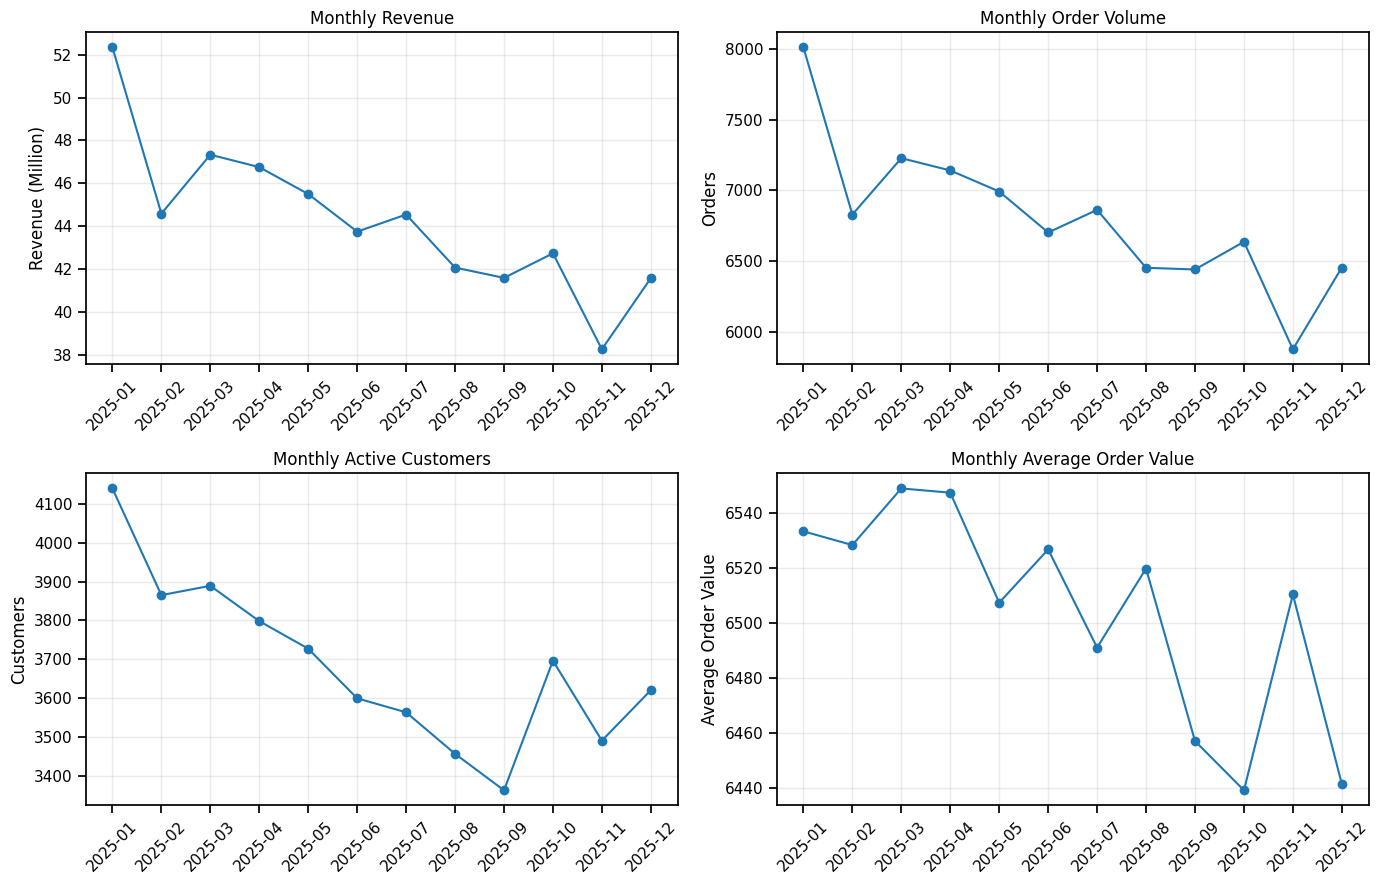

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(monthly['month'], monthly['revenue'] / 1_000_000, marker='o')
axes[0, 0].set_title('Monthly Revenue')
axes[0, 0].set_ylabel('Revenue (Million)')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(monthly['month'], monthly['orders'], marker='o')
axes[0, 1].set_title('Monthly Order Volume')
axes[0, 1].set_ylabel('Orders')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(monthly['month'], monthly['active_customers'], marker='o')
axes[1, 0].set_title('Monthly Active Customers')
axes[1, 0].set_ylabel('Customers')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].plot(monthly['month'], monthly['avg_order_value'], marker='o')
axes[1, 1].set_title('Monthly Average Order Value')
axes[1, 1].set_ylabel('Average Order Value')
axes[1, 1].tick_params(axis='x', rotation=45)

for ax in axes.flat:
    ax.grid(alpha=0.25)

plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/monthly_decomposition.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

### Portfolio Figure: Revenue, Orders & Active Customers

I combined these three monthly measures in one chart because their overall movement is easier to compare this way.

Revenue uses the left axis, while orders and active customers use the right axis because they are counts. The chart is created directly from the `monthly` dataframe and saved for the portfolio.


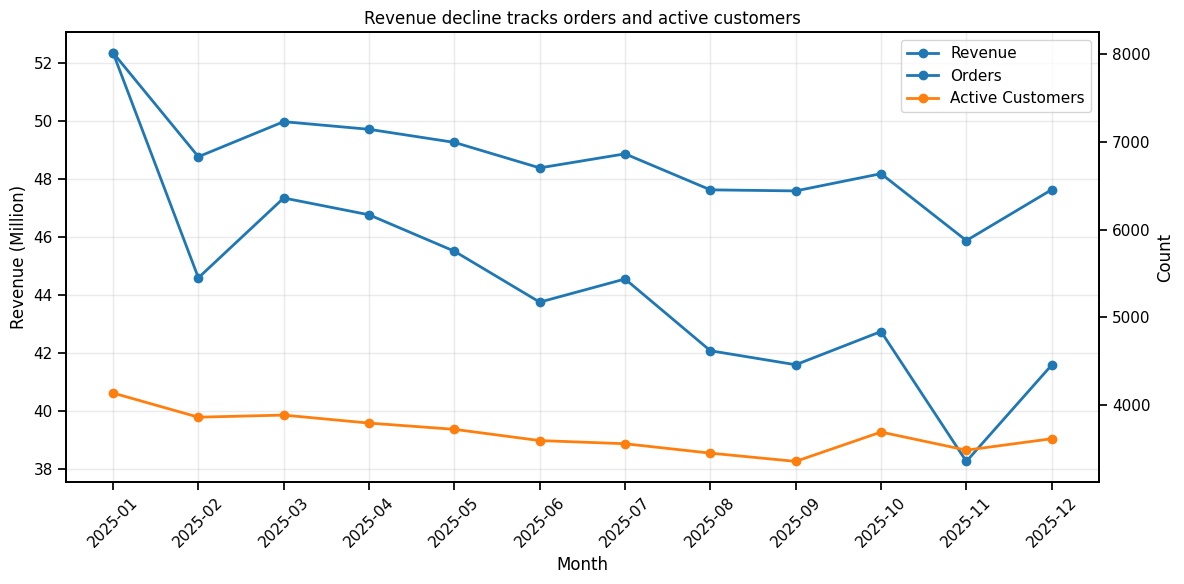

Saved portfolio chart to: /content/drive/MyDrive/Cafe_Customer_Analytics/images/monthly_activity_trend.png


In [11]:
# Portfolio-ready combined trend chart
# Combined monthly trend chart

required_columns = {'month', 'revenue', 'orders', 'active_customers'}
missing_columns = required_columns - set(monthly.columns)

if missing_columns:
    raise ValueError(
        f"monthly is missing required columns: {sorted(missing_columns)}"
    )

fig, ax1 = plt.subplots(figsize=(12, 6))

# Revenue — left y-axis
line1 = ax1.plot(
    monthly['month'],
    monthly['revenue'] / 1_000_000,
    marker='o',
    linewidth=2,
    label='Revenue'
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (Million)')
ax1.set_title('Revenue decline tracks orders and active customers')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(alpha=0.25)

# Orders and active customers — right y-axis
ax2 = ax1.twinx()

line2 = ax2.plot(
    monthly['month'],
    monthly['orders'],
    marker='o',
    linewidth=2,
    label='Orders'
)

line3 = ax2.plot(
    monthly['month'],
    monthly['active_customers'],
    marker='o',
    linewidth=2,
    label='Active Customers'
)

ax2.set_ylabel('Count')

# One combined legend
lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right')

plt.tight_layout()

# Save figure for portfolio
portfolio_chart_path = f'{IMAGE_DIR}/monthly_activity_trend.png'
plt.savefig(portfolio_chart_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Saved portfolio chart to: {portfolio_chart_path}")


In [12]:
# Quantify January-to-December change
jan = monthly.iloc[0]
dec = monthly.iloc[-1]

trend_change = pd.DataFrame({
    'Metric': ['Revenue', 'Orders', 'Active Customers', 'Average Order Value'],
    'Jan': [jan['revenue'], jan['orders'], jan['active_customers'], jan['avg_order_value']],
    'Dec': [dec['revenue'], dec['orders'], dec['active_customers'], dec['avg_order_value']]
})

trend_change['Change %'] = (
    (trend_change['Dec'] / trend_change['Jan']) - 1
) * 100

display(trend_change.round(2))

,Metric,Jan,Dec,Change %
0,Revenue,"52,345,260.000","41,572,220.000",-20.580
1,Orders,"8,012.000","6,454.000",-19.450
2,Active Customers,"4,140.000","3,620.000",-12.560
3,Average Order Value,"6,533.360","6,441.310",-1.410


### What I noticed

I wanted to check whether the revenue decline came from customers spending less per order or from lower customer activity.

Because average order value stayed fairly stable while orders and active customers fell, the bigger issue appeared to be lower activity rather than a large drop in spending per transaction.


## 5. Customer Concentration & Pareto Analysis

In [13]:
customer_value = orders.groupby('user_id').agg(
    total_spending=('final_amount', 'sum'),
    total_orders=('order_id', 'count'),
    avg_order_value=('final_amount', 'mean')
).reset_index()

customer_value = customer_value.sort_values(
    'total_spending',
    ascending=False
).reset_index(drop=True)

customer_value['cumulative_revenue_pct'] = (
    customer_value['total_spending'].cumsum()
    / customer_value['total_spending'].sum()
    * 100
)

customer_value['cumulative_customer_pct'] = (
    (customer_value.index + 1)
    / len(customer_value)
    * 100
)

top_20_n = int(np.ceil(len(customer_value) * 0.20))
top_20_share = (
    customer_value.head(top_20_n)['total_spending'].sum()
    / customer_value['total_spending'].sum()
    * 100
)

print(f"Top 20% of customers generate {top_20_share:.1f}% of total revenue.")

Top 20% of customers generate 34.8% of total revenue.


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/pareto_curve.png


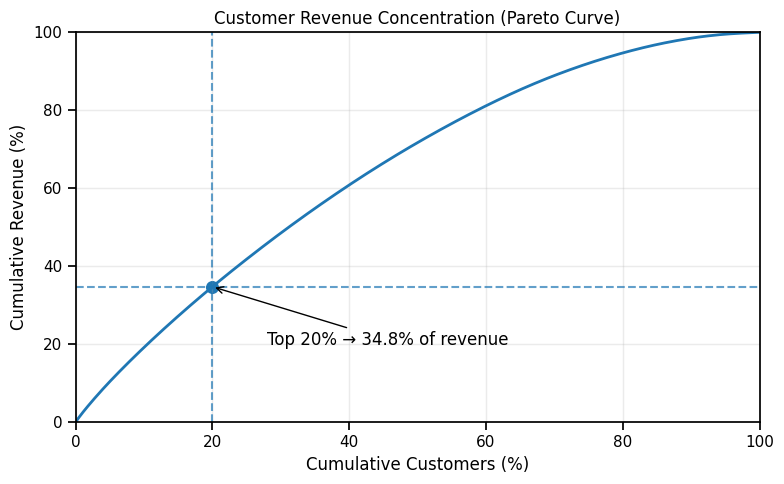

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    customer_value['cumulative_customer_pct'],
    customer_value['cumulative_revenue_pct'],
    linewidth=2
)

plt.axvline(20, linestyle='--', alpha=0.7)
plt.axhline(top_20_share, linestyle='--', alpha=0.7)

plt.scatter([20], [top_20_share], s=70)
plt.annotate(
    f'Top 20% → {top_20_share:.1f}% of revenue',
    (20, top_20_share),
    xytext=(28, max(10, top_20_share - 15)),
    arrowprops=dict(arrowstyle='->')
)

plt.title('Customer Revenue Concentration (Pareto Curve)')
plt.xlabel('Cumulative Customers (%)')
plt.ylabel('Cumulative Revenue (%)')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(alpha=0.25)
plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/pareto_curve.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

In [15]:
# Behavioral customer tiers based on order frequency
customer_behavior = orders.groupby('user_id').agg(
    visits=('order_id', 'count'),
    total_spend=('final_amount', 'sum'),
    avg_ticket=('final_amount', 'mean')
).reset_index()

customer_behavior['frequency_tier'] = pd.qcut(
    customer_behavior['visits'].rank(method='first'),
    q=[0, 0.5, 0.8, 1],
    labels=['Light', 'Medium', 'Heavy']
)

frequency_summary = customer_behavior.groupby(
    'frequency_tier',
    observed=False
).agg(
    customers=('user_id', 'count'),
    avg_visits=('visits', 'mean'),
    avg_ticket=('avg_ticket', 'mean'),
    total_revenue=('total_spend', 'sum')
).reset_index()

frequency_summary['revenue_share_pct'] = (
    frequency_summary['total_revenue']
    / frequency_summary['total_revenue'].sum()
    * 100
)

display(frequency_summary.round(2))

,frequency_tier,customers,avg_visits,avg_ticket,total_revenue,revenue_share_pct
0,Light,3000,6.760,"8,035.480",158665420,29.880
1,Medium,1800,17.280,"6,570.400",202578860,38.150
2,Heavy,1200,25.200,"5,622.550",169756070,31.970


## 6. Product, Channel, Store & Time Analysis

In [16]:
category_summary = orders.groupby('category').agg(
    revenue=('final_amount', 'sum'),
    orders=('order_id', 'count'),
    customers=('user_id', 'nunique')
).sort_values('revenue', ascending=False)

category_summary['revenue_share_pct'] = (
    category_summary['revenue'] / category_summary['revenue'].sum() * 100
)

display(category_summary.round(2))

,revenue,orders,customers,revenue_share_pct
category,,,,
Coffee,274607670,43851,5530,51.720
Beverage,81850060,12003,4889,15.410
Bakery,73397610,11538,4426,13.820
Dessert,69943750,9823,4437,13.170
Signature,31201260,4408,3018,5.880


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/category_analysis.png


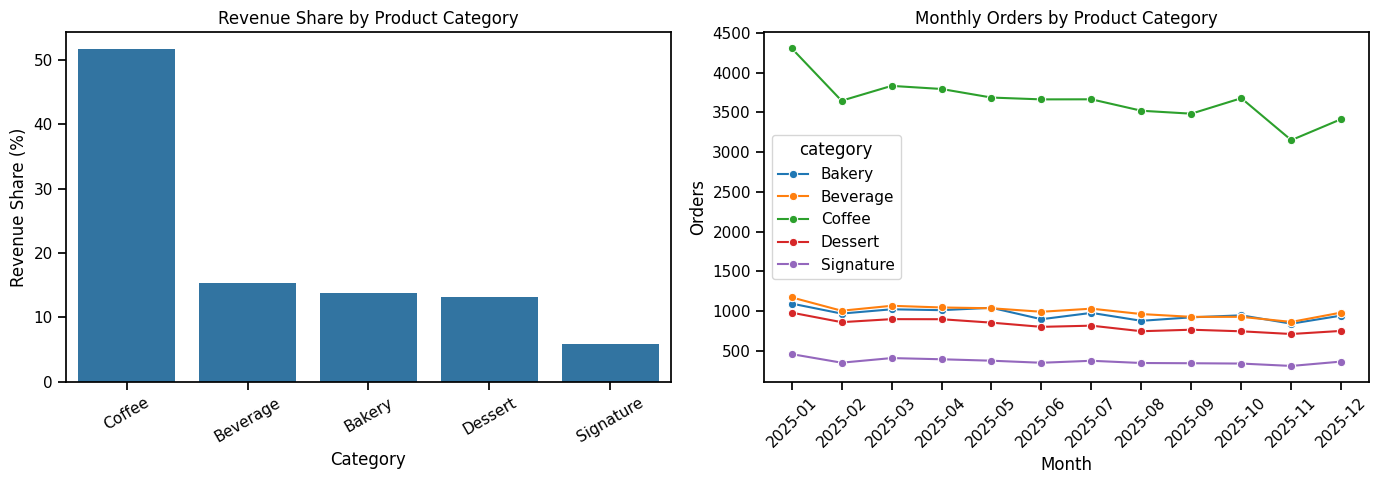

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_plot = category_summary.reset_index()

sns.barplot(
    data=category_plot,
    x='category',
    y='revenue_share_pct',
    ax=axes[0]
)
axes[0].set_title('Revenue Share by Product Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Revenue Share (%)')
axes[0].tick_params(axis='x', rotation=30)

category_month = orders.groupby(
    ['month', 'category']
)['order_id'].count().reset_index(name='orders')

sns.lineplot(
    data=category_month,
    x='month',
    y='orders',
    hue='category',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Monthly Orders by Product Category')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/category_analysis.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

In [18]:
# Category growth from January to December
category_pivot = orders.groupby(
    ['month', 'category']
)['order_id'].count().unstack(fill_value=0)

category_growth = pd.DataFrame({
    'January Orders': category_pivot.iloc[0],
    'December Orders': category_pivot.iloc[-1]
})

category_growth['Jan-Dec Change %'] = (
    category_growth['December Orders']
    / category_growth['January Orders']
    - 1
) * 100

display(category_growth.sort_values('Jan-Dec Change %', ascending=False).round(2))

,January Orders,December Orders,Jan-Dec Change %
category,,,
Bakery,1094,943,-13.800
Beverage,1172,981,-16.300
Signature,458,364,-20.520
Coffee,4308,3416,-20.710
Dessert,980,750,-23.470


In [19]:
order_source_summary = orders.groupby('order_source').agg(
    revenue=('final_amount', 'sum'),
    orders=('order_id', 'count'),
    avg_order_value=('final_amount', 'mean')
).sort_values('revenue', ascending=False)

store_summary = orders.groupby('store_type').agg(
    revenue=('final_amount', 'sum'),
    orders=('order_id', 'count'),
    customers=('user_id', 'nunique'),
    avg_order_value=('final_amount', 'mean')
).sort_values('revenue', ascending=False)

print("Order Source")
display(order_source_summary.round(2))

print("\nStore Type")
display(store_summary.round(2))

Order Source


,revenue,orders,avg_order_value
order_source,,,
Mobile_App,319156180,49133,"6,495.760"
Kiosk,115936160,17760,"6,527.940"
POS,95908010,14730,"6,511.070"



Store Type


,revenue,orders,customers,avg_order_value
store_type,,,,
오피스,210835680,36578,4617,"5,764.000"
대학가,160403990,21860,4765,"7,337.790"
주거,84526140,13262,4660,"6,373.560"
관광지,75234540,9923,4420,"7,581.830"


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/time_analysis.png


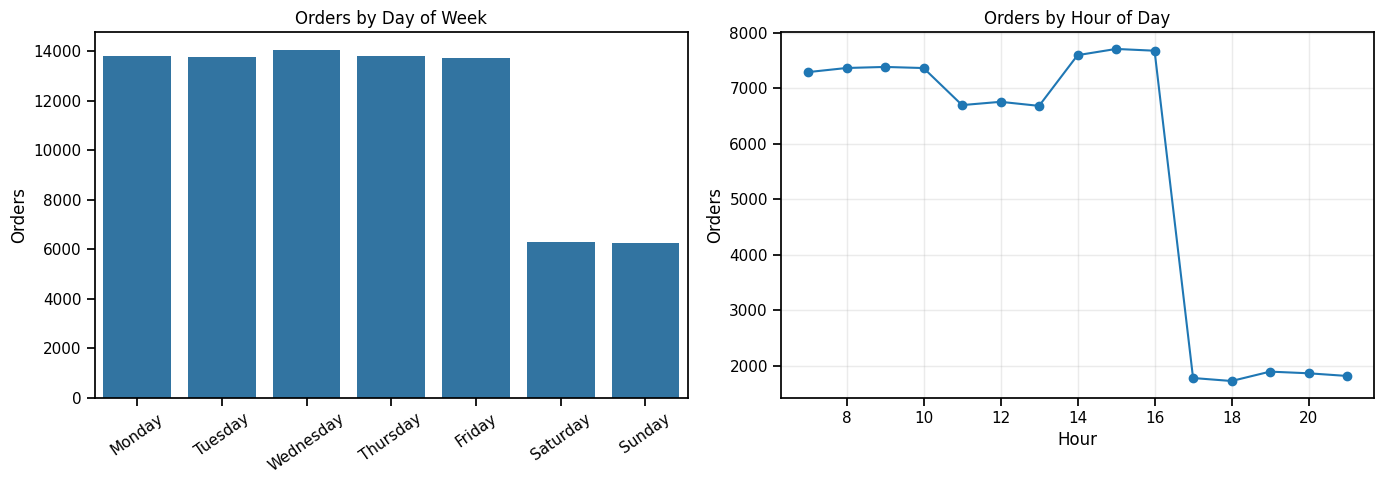

In [20]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

weekday_summary = orders.groupby('day_of_week').agg(
    revenue=('final_amount', 'sum'),
    orders=('order_id', 'count')
).reindex(day_order)

hourly_summary = orders.groupby('hour').agg(
    revenue=('final_amount', 'sum'),
    orders=('order_id', 'count')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=weekday_summary.index,
    y=weekday_summary['orders'],
    ax=axes[0]
)
axes[0].set_title('Orders by Day of Week')
axes[0].set_xlabel('')
axes[0].set_ylabel('Orders')
axes[0].tick_params(axis='x', rotation=35)

axes[1].plot(hourly_summary.index, hourly_summary['orders'], marker='o')
axes[1].set_title('Orders by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Orders')
axes[1].grid(alpha=0.25)

plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/time_analysis.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

## 7. Customer Behavioral Profile

In [21]:
customer_profile = orders.groupby('user_id').agg(
    total_spending=('final_amount', 'sum'),
    total_orders=('order_id', 'count'),
    avg_order_value=('final_amount', 'mean'),
    first_order=('order_received_at', 'min'),
    last_order=('order_received_at', 'max'),
    reorder_rate=('is_reorder', 'mean'),
    category_diversity=('category', 'nunique')
).reset_index()

display(customer_profile.head())
display(customer_profile.describe())

,user_id,total_spending,total_orders,avg_order_value,first_order,last_order,reorder_rate,category_diversity
0,USER_00000,63870,6,"10,645.000",2025-02-16 08:22:36,2025-11-23 12:35:50,0.000,4
1,USER_00001,60600,10,"6,060.000",2025-04-16 14:43:53,2025-12-11 07:57:31,0.200,5
2,USER_00002,36920,5,"7,384.000",2025-03-26 19:30:16,2025-10-04 12:08:31,0.600,3
3,USER_00003,154060,16,"9,628.750",2025-01-18 15:15:42,2025-11-21 21:10:15,0.500,5
4,USER_00004,149210,27,"5,526.296",2025-01-06 14:10:50,2025-12-23 12:38:48,0.926,4


,total_spending,total_orders,avg_order_value,first_order,last_order,reorder_rate,category_diversity
count,"6,000.000","6,000.000","6,000.000",6000,6000,"6,000.000","6,000.000"
mean,"88,500.058",13.604,"7,113.370",2025-01-30 08:33:23.450499840,2025-10-25 22:55:51.528666880,0.552,3.717
min,"3,180.000",1.000,"3,180.000",2025-01-01 07:01:29,2025-01-01 15:11:10,0.000,1.000
25%,"51,285.000",7.000,"5,624.917",2025-01-07 20:36:54,2025-11-04 13:41:07.750000128,0.333,3.000
50%,"89,740.000",13.000,"6,892.750",2025-01-17 16:32:53.500000,2025-12-09 16:51:06,0.600,4.000
75%,"121,675.000",20.000,"8,401.696",2025-02-07 14:07:20.750000128,2025-12-23 15:24:38,0.783,5.000
max,"279,920.000",39.000,"16,000.000",2025-09-28 09:35:57,2025-12-31 21:53:45,1.000,5.000
std,"46,604.112",8.059,"1,827.580",NaN,NaN,0.295,1.138


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/customer_behavior_profile.png


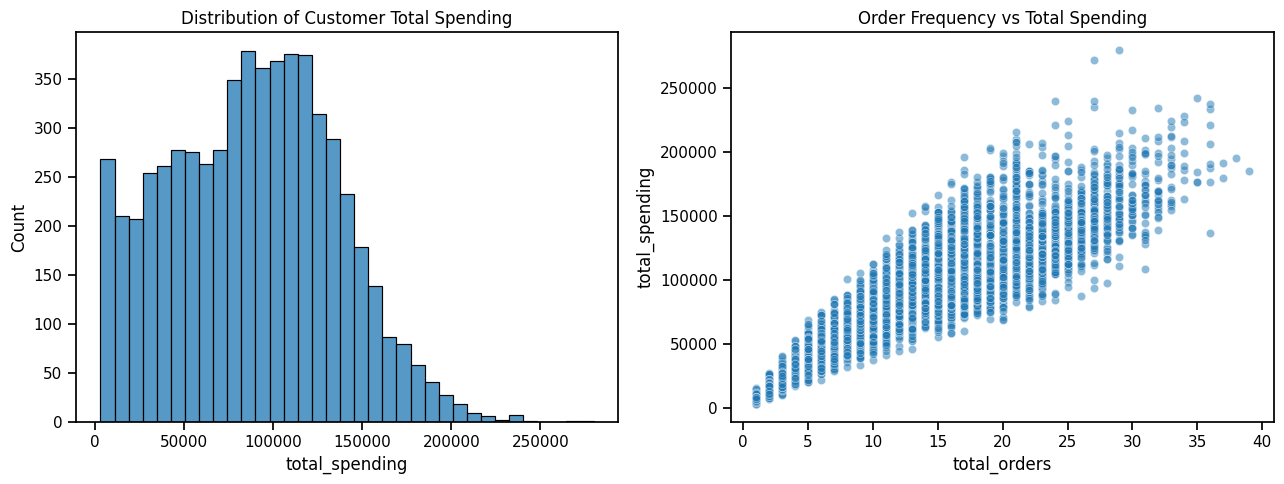

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    customer_profile['total_spending'],
    bins=35,
    ax=axes[0]
)
axes[0].set_title('Distribution of Customer Total Spending')

sns.scatterplot(
    data=customer_profile,
    x='total_orders',
    y='total_spending',
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title('Order Frequency vs Total Spending')

plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/customer_behavior_profile.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

## 8. Customer Segmentation with K-Means

For segmentation, I used an RFM-style set of customer behavior features:

- **Recency** — days since the latest purchase
- **Frequency** — number of orders
- **Monetary** — total spending
- **Average Order Value**
- **Reorder Rate**

I log-transformed Frequency and Monetary before scaling because they were skewed.

I checked both the Elbow Method and Silhouette Score when choosing the number of clusters. PCA is only used to visualize the groups in two dimensions; the clustering itself uses the standardized behavior features.


In [23]:
reference_date = orders['order_received_at'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('user_id').agg(
    Recency=('order_received_at', lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'count'),
    Monetary=('final_amount', 'sum'),
    AvgOrderValue=('final_amount', 'mean'),
    ReorderRate=('is_reorder', 'mean')
).reset_index()

rfm_model = rfm[
    ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'ReorderRate']
].copy()

rfm_model['Frequency'] = np.log1p(rfm_model['Frequency'])
rfm_model['Monetary'] = np.log1p(rfm_model['Monetary'])

cluster_scaler = StandardScaler()
rfm_scaled = cluster_scaler.fit_transform(rfm_model)

display(rfm.head())

,user_id,Recency,Frequency,Monetary,AvgOrderValue,ReorderRate
0,USER_00000,39,6,63870,"10,645.000",0.000
1,USER_00001,21,10,60600,"6,060.000",0.200
2,USER_00002,89,5,36920,"7,384.000",0.600
3,USER_00003,41,16,154060,"9,628.750",0.500
4,USER_00004,9,27,149210,"5,526.296",0.926


In [24]:
cluster_diagnostics = []

for k in range(2, 7):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels = km.fit_predict(rfm_scaled)

    cluster_diagnostics.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette_score': silhouette_score(rfm_scaled, labels)
    })

cluster_diagnostics = pd.DataFrame(cluster_diagnostics)
display(cluster_diagnostics.round(4))

,k,inertia,silhouette_score
0,2,"16,946.605",0.445
1,3,"11,910.158",0.372
2,4,"10,239.342",0.375
3,5,"8,611.277",0.326
4,6,"7,851.506",0.333


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/cluster_diagnostics.png


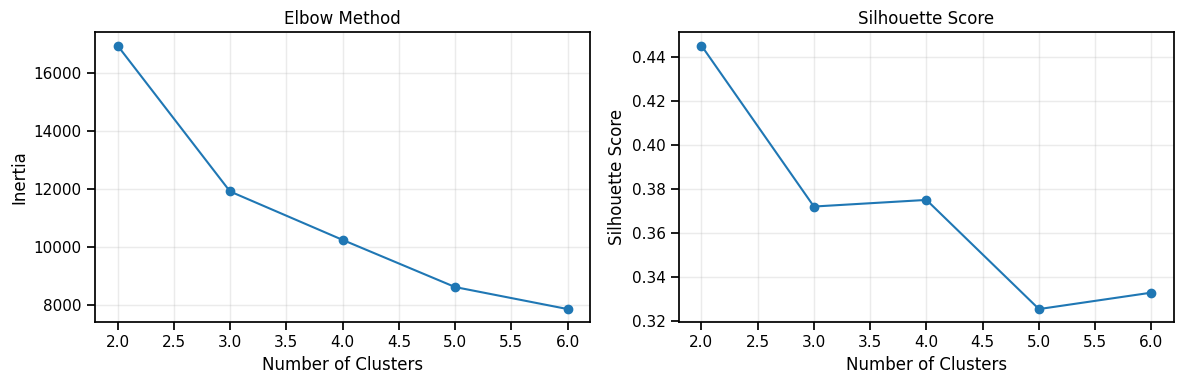

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    cluster_diagnostics['k'],
    cluster_diagnostics['inertia'],
    marker='o'
)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.25)

axes[1].plot(
    cluster_diagnostics['k'],
    cluster_diagnostics['silhouette_score'],
    marker='o'
)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.25)

plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/cluster_diagnostics.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

In [26]:
best_k = int(
    cluster_diagnostics.loc[
        cluster_diagnostics['silhouette_score'].idxmax(),
        'k'
    ]
)

print("Best k by Silhouette Score:", best_k)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('cluster').agg(
    customers=('user_id', 'count'),
    avg_recency=('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary=('Monetary', 'mean'),
    avg_order_value=('AvgOrderValue', 'mean'),
    avg_reorder_rate=('ReorderRate', 'mean')
).round(2)

display(cluster_summary)

Best k by Silhouette Score: 2


,customers,avg_recency,avg_frequency,avg_monetary,avg_order_value,avg_reorder_rate
cluster,,,,,,
0,1721,174.570,4.090,"34,113.530","8,383.280",0.350
1,4279,24.580,17.430,"110,374.150","6,602.620",0.630


Variance explained by two PCA components: 83.8%
Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/pca_segments.png


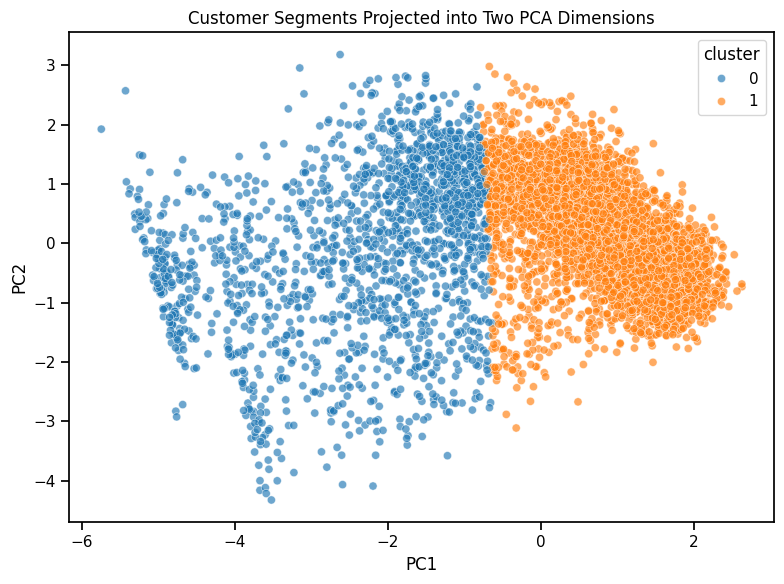

In [27]:
# PCA visualization of the clusters
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm['PC1'] = rfm_pca[:, 0]
rfm['PC2'] = rfm_pca[:, 1]

print(
    "Variance explained by two PCA components:",
    f"{pca.explained_variance_ratio_.sum():.1%}"
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    alpha=0.65,
    s=35
)

plt.title('Customer Segments Projected into Two PCA Dimensions')
plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/pca_segments.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

### How I interpreted the clusters

K-Means does not automatically tell me which group is “loyal” or “at-risk.”

I assigned the business labels only after comparing each cluster's recency, order frequency, spending, and reorder behavior.


## 9. Churn Definition & Feature Engineering

I separated the data into two time periods:

- **Observation period:** January–September 2025
- **Outcome period:** October–December 2025

A customer is labeled **churn = 1** if they purchased during the observation period but did not return during the outcome period.

Only information available by the end of September is used to build the model features. This keeps future information out of the prediction.


In [28]:
observation_end = pd.Timestamp('2025-09-30 23:59:59')
outcome_start = pd.Timestamp('2025-10-01 00:00:00')

observation = orders[
    orders['order_received_at'] <= observation_end
].copy()

outcome = orders[
    orders['order_received_at'] >= outcome_start
].copy()

print("Observation-period orders:", f"{len(observation):,}")
print("Outcome-period orders:", f"{len(outcome):,}")

Observation-period orders: 62,658
Outcome-period orders: 18,965


In [29]:
def mode_or_nan(series):
    values = series.dropna().mode()
    return values.iloc[0] if len(values) else np.nan

customer_features = observation.groupby('user_id').agg(
    # Core behavioral variables
    recency=('order_received_at', lambda x: (observation_end - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('final_amount', 'sum'),
    avg_order_value=('final_amount', 'mean'),
    reorder_rate=('is_reorder', 'mean'),

    # Engagement / diversity variables
    active_months=('order_received_at', lambda x: x.dt.to_period('M').nunique()),
    category_diversity=('category', 'nunique'),
    mobile_share=('order_source', lambda x: (x == 'Mobile_App').mean()),
    delivery_share=('order_type', lambda x: (x == 'Delivery').mean()),
    coupon_share=('discount_type', lambda x: (x == 'Coupon').mean()),

    # Customer profile variables
    age=('age', 'median'),
    gender=('gender', mode_or_nan),
    membership=('membership', mode_or_nan),
    store_type=('store_type', mode_or_nan),
    order_source=('order_source', mode_or_nan),
    favorite_category=('category', mode_or_nan)
).reset_index()

returned_customers = set(outcome['user_id'].unique())

customer_features['churn'] = (
    ~customer_features['user_id'].isin(returned_customers)
).astype(int)

display(customer_features.head())

,user_id,recency,frequency,monetary,avg_order_value,reorder_rate,active_months,category_diversity,mobile_share,delivery_share,coupon_share,age,gender,membership,store_type,order_source,favorite_category,churn
0,USER_00000,45,4,44260,"11,065.000",0.000,3,3,0.000,0.250,0.000,40.000,F,Non-member,주거,POS,Beverage,0
1,USER_00001,21,6,35160,"5,860.000",0.167,4,4,0.833,0.000,0.500,29.000,M,Gold,대학가,Mobile_App,Coffee,0
2,USER_00002,106,4,29530,"7,382.500",0.500,3,3,0.500,0.250,0.250,19.000,M,Bronze,관광지,Mobile_App,Beverage,0
3,USER_00003,18,12,116650,"9,720.833",0.417,8,4,0.917,0.083,0.583,23.000,F,Gold,대학가,Mobile_App,Coffee,0
4,USER_00004,0,20,110280,"5,514.000",0.900,8,4,0.350,0.400,0.050,37.000,F,Non-member,오피스,Kiosk,Coffee,0


In [30]:
churn_summary = customer_features['churn'].value_counts().rename_axis(
    'churn'
).reset_index(name='customers')

churn_summary['percentage'] = (
    churn_summary['customers']
    / churn_summary['customers'].sum()
    * 100
)

display(churn_summary)

print(
    "Overall churn rate:",
    f"{customer_features['churn'].mean():.1%}"
)

,churn,customers,percentage
0,0,4840,80.667
1,1,1160,19.333


Overall churn rate: 19.3%


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/churn_distribution.png


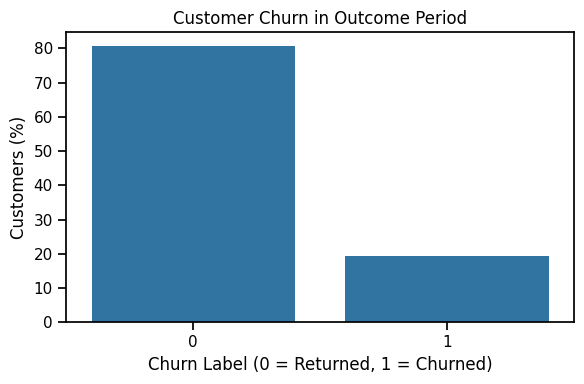

In [31]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=churn_summary,
    x='churn',
    y='percentage'
)

plt.title('Customer Churn in Outcome Period')
plt.xlabel('Churn Label (0 = Returned, 1 = Churned)')
plt.ylabel('Customers (%)')
plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/churn_distribution.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

## 10. Machine Learning with Cross-Validation

I compared three models:

1. Logistic Regression
2. Decision Tree
3. Random Forest

### Preprocessing

For numeric features, I used median imputation and standardization. For categorical features, I used most-frequent imputation and one-hot encoding.

I kept these steps inside a pipeline so preprocessing is learned from the training data only.

### Cross-validation

Instead of depending on one train/test split, I used 5-fold stratified cross-validation to compare the models more reliably before checking the final held-out test set.


In [32]:
numeric_features = [
    'recency',
    'frequency',
    'monetary',
    'avg_order_value',
    'reorder_rate',
    'active_months',
    'category_diversity',
    'mobile_share',
    'delivery_share',
    'coupon_share',
    'age'
]

categorical_features = [
    'gender',
    'membership',
    'store_type',
    'order_source',
    'favorite_category'
]

feature_columns = numeric_features + categorical_features

X = customer_features[feature_columns]
y = customer_features['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training customers:", len(X_train))
print("Held-out test customers:", len(X_test))
print("Training churn rate:", f"{y_train.mean():.1%}")
print("Test churn rate:", f"{y_test.mean():.1%}")

Training customers: 4800
Held-out test customers: 1200
Training churn rate: 19.3%
Test churn rate: 19.3%


In [33]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
}

In [34]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1': 'f1',
    'ROC_AUC': 'roc_auc'
}

cv_rows = []
pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipelines[model_name] = pipeline

    cv_result = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    row = {'Model': model_name}

    for metric in scoring.keys():
        row[f'CV {metric}'] = cv_result[f'test_{metric}'].mean()
        row[f'CV {metric} SD'] = cv_result[f'test_{metric}'].std()

    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values(
    'CV ROC_AUC',
    ascending=False
)

display(cv_results.round(3))

,Model,CV Accuracy,CV Accuracy SD,CV Precision,CV Precision SD,CV Recall,CV Recall SD,CV F1,CV F1 SD,CV ROC_AUC,CV ROC_AUC SD
0,Logistic Regression,0.913,0.005,0.732,0.015,0.866,0.011,0.793,0.010,0.965,0.002
2,Random Forest,0.906,0.005,0.713,0.014,0.862,0.024,0.780,0.013,0.962,0.003
1,Decision Tree,0.875,0.011,0.620,0.025,0.924,0.018,0.741,0.014,0.960,0.003


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/model_cross_validation.png


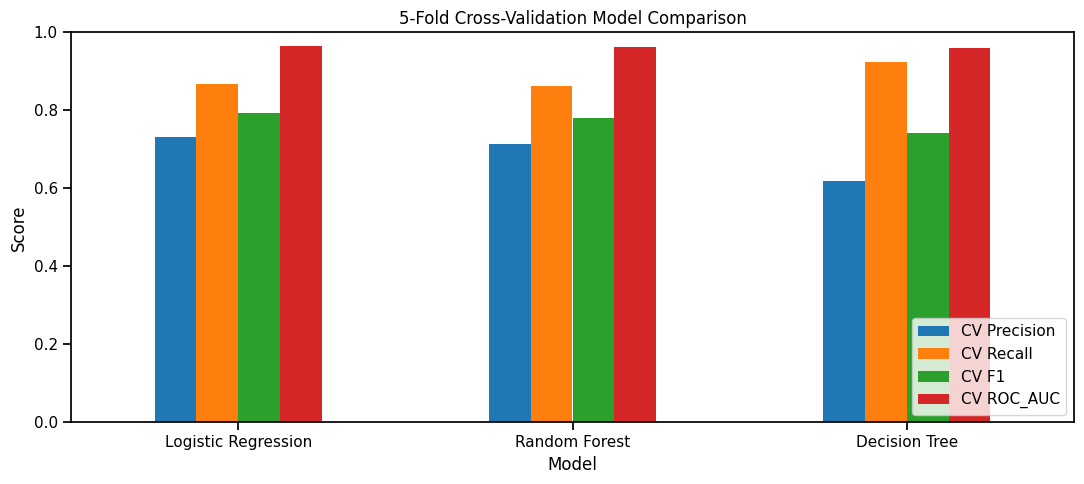

In [35]:
# Visualize the main cross-validation metrics
cv_plot = cv_results.set_index('Model')[
    ['CV Precision', 'CV Recall', 'CV F1', 'CV ROC_AUC']
]

cv_plot.plot(
    kind='bar',
    figsize=(11, 5)
)

plt.title('5-Fold Cross-Validation Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/model_cross_validation.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

### Choosing the model

I selected the model with the highest mean cross-validated **ROC-AUC**.

I used ROC-AUC because I wanted the model to rank higher-risk customers above lower-risk customers, not just make a single yes/no prediction.

I also kept Precision, Recall, and F1 in the comparison because a retention campaign has to balance missed churners against contacting too many false positives.


In [36]:
best_model_name = cv_results.iloc[0]['Model']
best_model = pipelines[best_model_name]

print("Selected model:", best_model_name)

best_model.fit(X_train, y_train)

Selected model: Logistic Regression


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['recency', 'frequency',
                                                   'monetary',
                                                   'avg_order_value',
                                                   'reorder_rate',
                                                   'active_months',
                                                   'category_diversity',
                                                   'mobile_share',
                                                   'delivery_share',
                                                   'coupon_share', 'age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'membership',
                                                   'store_type', 'order_source',
                                                   'favorite_category'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

## 11. Held-Out Test Evaluation

In [37]:
test_rows = []

for model_name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)
    prob = pipeline.predict_proba(X_test)[:, 1]

    test_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC_AUC': roc_auc_score(y_test, prob)
    })

test_results = pd.DataFrame(test_rows).sort_values(
    'ROC_AUC',
    ascending=False
)

display(test_results.round(3))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.908,0.734,0.819,0.774,0.959
2,Random Forest,0.912,0.735,0.849,0.788,0.958
1,Decision Tree,0.902,0.686,0.905,0.781,0.955


In [38]:
# Final held-out predictions from the selected model
best_model.fit(X_train, y_train)

test_pred = best_model.predict(X_test)
test_prob = best_model.predict_proba(X_test)[:, 1]

print("Selected model:", best_model_name)
print()
print(classification_report(y_test, test_pred))

Selected model: Logistic Regression

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       968
           1       0.73      0.82      0.77       232

    accuracy                           0.91      1200
   macro avg       0.84      0.87      0.86      1200
weighted avg       0.91      0.91      0.91      1200



Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/confusion_matrix.png


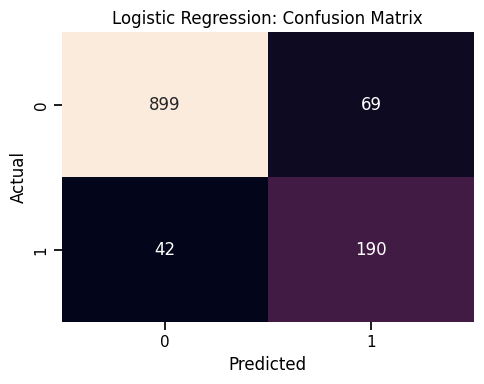

In [39]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cbar=False
)

plt.title(f'{best_model_name}: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/confusion_matrix.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/roc_pr_curves.png


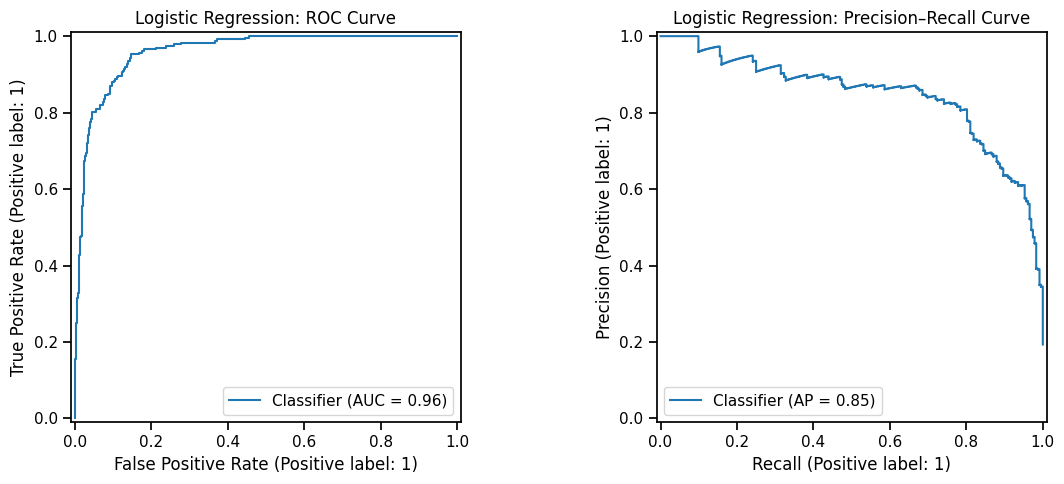

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test,
    test_prob,
    ax=axes[0]
)
axes[0].set_title(f'{best_model_name}: ROC Curve')

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_prob,
    ax=axes[1]
)
axes[1].set_title(f'{best_model_name}: Precision–Recall Curve')

plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/roc_pr_curves.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

## 12. Churn Driver Interpretation

I used permutation importance to see which features had the biggest effect on model performance.

The idea is simple: if shuffling one feature causes a large drop in performance, that feature was important to the model.


In [41]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=12,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False)

display(importance.round(4))

,Feature,Importance,Std
0,recency,0.392,0.012
1,frequency,0.027,0.004
5,active_months,0.005,0.001
13,store_type,0.005,0.002
12,membership,0.001,0.001
8,delivery_share,0.000,0.000
15,favorite_category,0.000,0.000
2,monetary,0.000,0.001
14,order_source,0.000,0.000
10,age,0.000,0.000


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/feature_importance.png


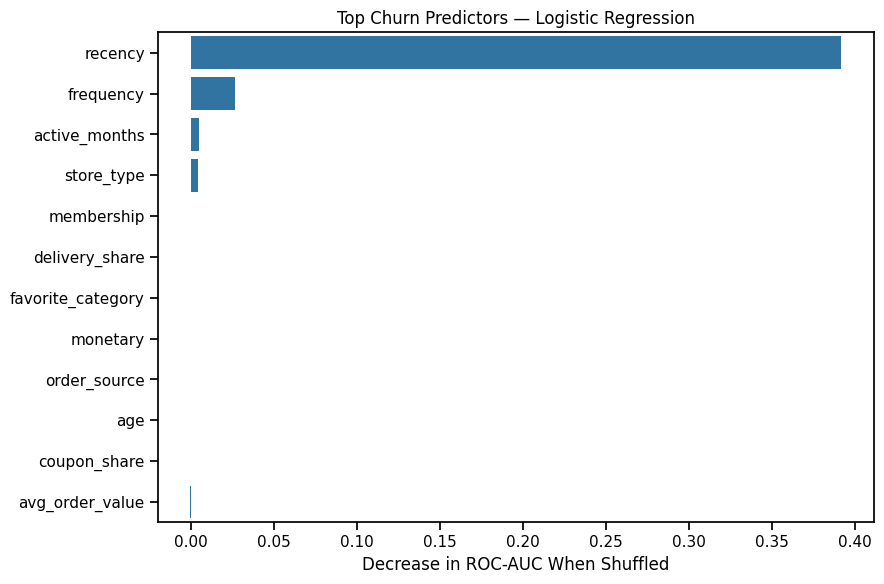

In [42]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=importance.head(12),
    x='Importance',
    y='Feature'
)

plt.title(f'Top Churn Predictors — {best_model_name}')
plt.xlabel('Decrease in ROC-AUC When Shuffled')
plt.ylabel('')
plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/feature_importance.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

## 13. Customer Risk Prioritization

Churn probability alone does not tell me who should be contacted first.

To make the result more practical, I combined:
- predicted churn probability
- a simple three-month value proxy based on each customer's observed spending rate

The result is a priority score, not a guarantee of future revenue. I used it to identify customers who were both high-risk and financially meaningful.


In [43]:
# Refit selected model on all observation-period customers
best_model.fit(X, y)

customer_features['churn_probability'] = (
    best_model.predict_proba(X)[:, 1]
)

# Historical monthly spending rate during observation period
customer_features['monthly_spend_proxy'] = (
    customer_features['monetary']
    / customer_features['active_months'].clip(lower=1)
)

# Three-month revenue proxy
customer_features['three_month_value_proxy'] = (
    customer_features['monthly_spend_proxy'] * 3
)

# Expected value at risk heuristic
customer_features['value_at_risk_score'] = (
    customer_features['churn_probability']
    * customer_features['three_month_value_proxy']
)

risk_ranking = customer_features.sort_values(
    'value_at_risk_score',
    ascending=False
)

display(
    risk_ranking[
        [
            'user_id',
            'churn_probability',
            'three_month_value_proxy',
            'value_at_risk_score',
            'recency',
            'frequency',
            'monetary',
            'membership'
        ]
    ].head(20).round(2)
)

,user_id,churn_probability,three_month_value_proxy,value_at_risk_score,recency,frequency,monetary,membership
2861,USER_02861,0.970,"136,470.000","132,642.540",156,6,45490,Silver
3568,USER_03568,1.000,"111,420.000","111,372.220",259,3,37140,Bronze
1092,USER_01092,1.000,"108,390.000","108,351.890",242,7,36130,Gold
4722,USER_04722,1.000,"92,490.000","92,470.130",254,5,30830,Gold
1633,USER_01633,0.980,"87,520.000","86,134.400",183,10,87520,Silver
4629,USER_04629,1.000,"84,570.000","84,376.400",189,5,28190,Gold
4317,USER_04317,1.000,"80,940.000","80,896.080",255,2,26980,Bronze
5670,USER_05670,1.000,"81,150.000","80,886.600",213,5,54100,Gold
3392,USER_03392,1.000,"79,890.000","79,777.010",234,6,53260,Bronze
1776,USER_01776,1.000,"79,740.000","79,626.600",196,4,26580,Bronze


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/risk_map.png


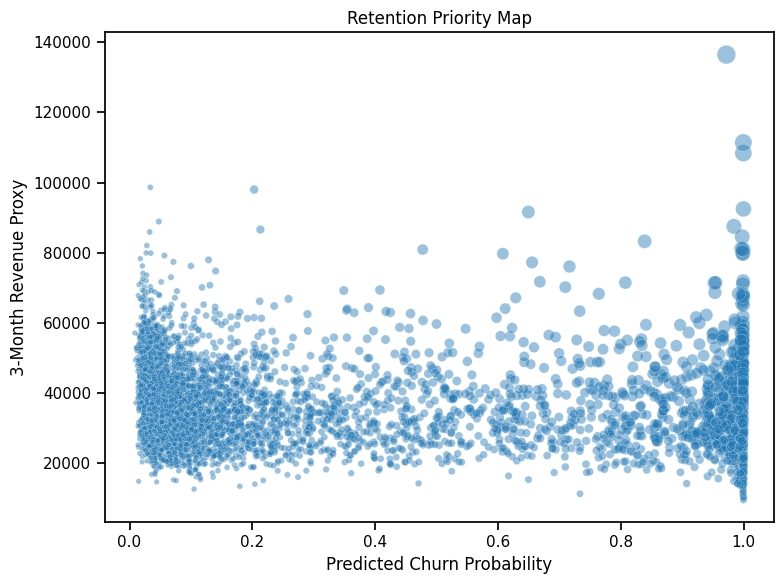

In [44]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=customer_features,
    x='churn_probability',
    y='three_month_value_proxy',
    size='value_at_risk_score',
    sizes=(15, 180),
    alpha=0.45,
    legend=False
)

plt.title('Retention Priority Map')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('3-Month Revenue Proxy')
plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/risk_map.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

In [45]:
# Example operational shortlist:
# customers in the top 10% by value-at-risk score

risk_cutoff = customer_features['value_at_risk_score'].quantile(0.90)

priority_customers = customer_features[
    customer_features['value_at_risk_score'] >= risk_cutoff
].sort_values(
    'value_at_risk_score',
    ascending=False
)

print("Priority customers:", len(priority_customers))
print(
    "Average churn probability:",
    f"{priority_customers['churn_probability'].mean():.1%}"
)

display(
    priority_customers[
        [
            'user_id',
            'churn_probability',
            'three_month_value_proxy',
            'value_at_risk_score'
        ]
    ].head(15).round(2)
)

Priority customers: 600
Average churn probability: 93.8%


,user_id,churn_probability,three_month_value_proxy,value_at_risk_score
2861,USER_02861,0.970,"136,470.000","132,642.540"
3568,USER_03568,1.000,"111,420.000","111,372.220"
1092,USER_01092,1.000,"108,390.000","108,351.890"
4722,USER_04722,1.000,"92,490.000","92,470.130"
1633,USER_01633,0.980,"87,520.000","86,134.400"
4629,USER_04629,1.000,"84,570.000","84,376.400"
4317,USER_04317,1.000,"80,940.000","80,896.080"
5670,USER_05670,1.000,"81,150.000","80,886.600"
3392,USER_03392,1.000,"79,890.000","79,777.010"
1776,USER_01776,1.000,"79,740.000","79,626.600"


## 14. Coupon Pilot Analysis

The coupon dataset includes customer ID, pilot group, coupon amount, and 30-day spending.

I compared the average spending of the different coupon groups.

> **Note:** I could not independently confirm that customers were randomly assigned to the groups, so I treat these results as descriptive rather than fully causal.


In [46]:
coupon = coupon_raw.copy()

coupon_summary = coupon.groupby(
    ['pilot_group', 'coupon_amount']
).agg(
    customers=('user_id', 'count'),
    avg_30d_spend=('campaign_spend_30d', 'mean'),
    median_30d_spend=('campaign_spend_30d', 'median'),
    std_30d_spend=('campaign_spend_30d', 'std')
).reset_index().sort_values('coupon_amount')

control_mean = coupon_summary.loc[
    coupon_summary['coupon_amount'] == 0,
    'avg_30d_spend'
].iloc[0]

coupon_summary['uplift_vs_control'] = (
    coupon_summary['avg_30d_spend'] - control_mean
)

coupon_summary['uplift_pct_vs_control'] = (
    coupon_summary['uplift_vs_control']
    / control_mean
    * 100
)

coupon_summary['incremental_spend_per_coupon_value'] = np.where(
    coupon_summary['coupon_amount'] > 0,
    coupon_summary['uplift_vs_control']
    / coupon_summary['coupon_amount'],
    np.nan
)

display(coupon_summary.round(2))

,pilot_group,coupon_amount,customers,avg_30d_spend,median_30d_spend,std_30d_spend,uplift_vs_control,uplift_pct_vs_control,incremental_spend_per_coupon_value
0,Control,0,1500,"9,476.490","9,625.000","4,053.190",0.000,0.000,NaN
1,Coupon_1000,1000,1500,"11,748.340","11,822.500","3,937.490","2,271.850",23.970,2.270
2,Coupon_2000,2000,1500,"13,099.340","13,082.500","4,039.190","3,622.850",38.230,1.810
3,Coupon_3000,3000,1500,"13,566.940","13,494.000","4,064.230","4,090.450",43.160,1.360


Saved: /content/drive/MyDrive/Cafe_Customer_Analytics/images/coupon_analysis.png


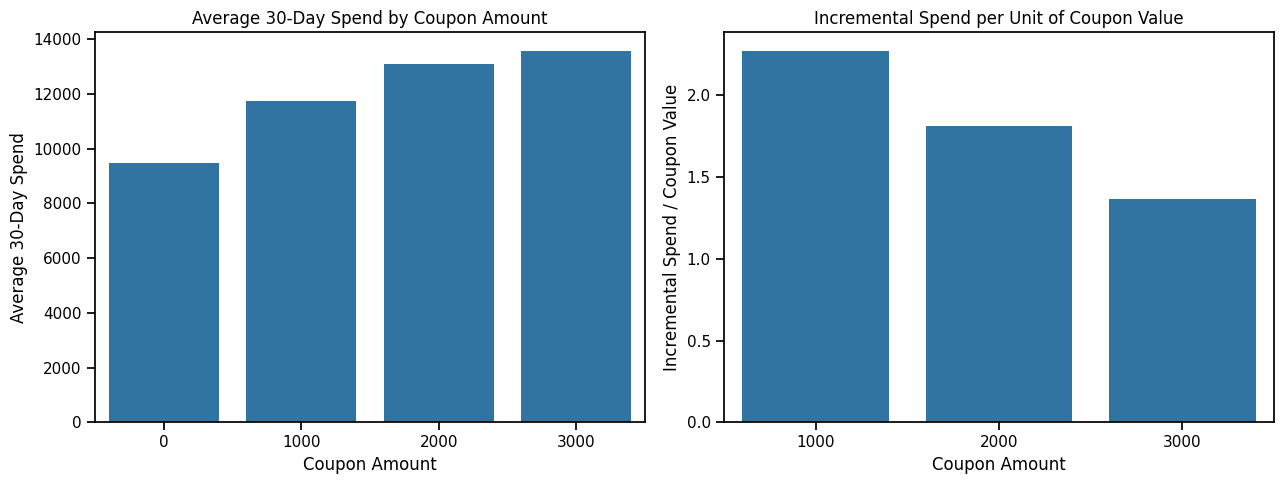

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=coupon_summary,
    x='coupon_amount',
    y='avg_30d_spend',
    ax=axes[0]
)
axes[0].set_title('Average 30-Day Spend by Coupon Amount')
axes[0].set_xlabel('Coupon Amount')
axes[0].set_ylabel('Average 30-Day Spend')

coupon_effect = coupon_summary[
    coupon_summary['coupon_amount'] > 0
]

sns.barplot(
    data=coupon_effect,
    x='coupon_amount',
    y='incremental_spend_per_coupon_value',
    ax=axes[1]
)
axes[1].set_title('Incremental Spend per Unit of Coupon Value')
axes[1].set_xlabel('Coupon Amount')
axes[1].set_ylabel('Incremental Spend / Coupon Value')

plt.tight_layout()
# Save figure
image_path = f'{IMAGE_DIR}/coupon_analysis.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f'Saved: {image_path}')

plt.show()

In [48]:
# Optional: check whether each pilot group contains the same number of customers
display(
    coupon.groupby('pilot_group')['user_id']
    .nunique()
    .sort_values(ascending=False)
)

,user_id
pilot_group,
Control,1500
Coupon_1000,1500
Coupon_2000,1500
Coupon_3000,1500


### Saved Portfolio Figures

After **Runtime → Run all**, the main charts are saved automatically to:

`MyDrive/Cafe_Customer_Analytics/images/`

I used these saved PNG files in the portfolio slides.


In [49]:
# Check saved portfolio images
expected_images = [
    'monthly_decomposition.png',
    'monthly_activity_trend.png',
    'pareto_curve.png',
    'category_analysis.png',
    'time_analysis.png',
    'customer_behavior_profile.png',
    'cluster_diagnostics.png',
    'pca_segments.png',
    'churn_distribution.png',
    'model_cross_validation.png',
    'confusion_matrix.png',
    'roc_pr_curves.png',
    'feature_importance.png',
    'risk_map.png',
    'coupon_analysis.png',
]

print("SAVED PORTFOLIO FIGURES")
print("-" * 60)

for filename in expected_images:
    path = f'{IMAGE_DIR}/{filename}'
    status = "✓" if os.path.exists(path) else "✗"
    print(f"{status} {path}")


SAVED PORTFOLIO FIGURES
------------------------------------------------------------
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/monthly_decomposition.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/monthly_activity_trend.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/pareto_curve.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/category_analysis.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/time_analysis.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/customer_behavior_profile.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/cluster_diagnostics.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/pca_segments.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/churn_distribution.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/model_cross_validation.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytics/images/confusion_matrix.png
✓ /content/drive/MyDrive/Cafe_Customer_Analytic

### Coupon interpretation

I looked at two separate questions:

1. Which coupon group had the highest observed 30-day spending?
2. Which coupon amount produced the most additional spending relative to the coupon value?

The largest coupon can increase spending the most while still being less efficient per unit of discount.

For a real business decision, I would also need product margin, redemption data, campaign cost, and confirmed random assignment.


## 15. Possible Actions

Based on the analysis, I would focus on targeted retention rather than giving the same offer to everyone.

### Retention
Start with customers who have both high churn probability and high value-at-risk.

### Customer groups
Use the behavioral clusters to separate active customers from customers who are starting to drift away.

### Product tracking
Look at both current revenue and the direction of category demand. A large category is not always a growing category.

### Coupon testing
Use the pilot results to design a follow-up experiment instead of assuming the biggest discount is automatically the best choice.

### Measurement
For a real retention campaign, I would define treatment and control groups, a fixed evaluation window, and clear success metrics such as return rate, incremental revenue, margin after discount, and cost per retained customer.


## 16. Limitations & Next Steps

### Limitations
1. The dataset is course-provided educational data, not audited production data.
2. Churn is defined here as no purchase during October–December. A real business might use a different time window.
3. I could not independently verify random assignment in the coupon pilot.
4. The dataset does not include full product cost, so I cannot calculate campaign profitability directly.
5. The value-at-risk score is a prioritization tool, not an estimate of guaranteed revenue saved.

### What I would do next
- Add product margin and cost data
- Validate the churn model on a later time period
- Calibrate churn probabilities
- Tune campaign thresholds using contact cost
- Run randomized retention experiments
- Track model performance over time


## 17. Executive Summary

In [50]:
# Executive summary

revenue_change = (
    monthly.iloc[-1]['revenue']
    / monthly.iloc[0]['revenue']
    - 1
) * 100

order_change = (
    monthly.iloc[-1]['orders']
    / monthly.iloc[0]['orders']
    - 1
) * 100

customer_change = (
    monthly.iloc[-1]['active_customers']
    / monthly.iloc[0]['active_customers']
    - 1
) * 100

aov_change = (
    monthly.iloc[-1]['avg_order_value']
    / monthly.iloc[0]['avg_order_value']
    - 1
) * 100

selected_test = test_results[
    test_results['Model'] == best_model_name
].iloc[0]

print("EXECUTIVE SUMMARY")
print("-" * 70)
print(f"1. 2025 Jan→Dec revenue change: {revenue_change:.1f}%")
print(f"2. 2025 Jan→Dec order-volume change: {order_change:.1f}%")
print(f"3. 2025 Jan→Dec active-customer change: {customer_change:.1f}%")
print(f"4. 2025 Jan→Dec average-order-value change: {aov_change:.1f}%")
print(f"5. Top 20% customer revenue share: {top_20_share:.1f}%")
print(f"6. Observed churn rate: {customer_features['churn'].mean():.1%}")
print(f"7. Selected churn model: {best_model_name}")
print(f"8. Held-out ROC-AUC: {selected_test['ROC_AUC']:.3f}")
print(f"9. Held-out Recall: {selected_test['Recall']:.3f}")
print(f"10. Priority retention list size: {len(priority_customers):,}")

EXECUTIVE SUMMARY
----------------------------------------------------------------------
1. 2025 Jan→Dec revenue change: -20.6%
2. 2025 Jan→Dec order-volume change: -19.4%
3. 2025 Jan→Dec active-customer change: -12.6%
4. 2025 Jan→Dec average-order-value change: -1.4%
5. Top 20% customer revenue share: 34.8%
6. Observed churn rate: 19.3%
7. Selected churn model: Logistic Regression
8. Held-out ROC-AUC: 0.959
9. Held-out Recall: 0.819
10. Priority retention list size: 600


## 18. Export Portfolio Outputs

The final cell saves the main result tables to Google Drive.

I use these files for the GitHub repository, portfolio PDF, and any follow-up analysis.


In [51]:
# Save portfolio-ready outputs
monthly.to_csv(
    f'{OUTPUT_DIR}/monthly_business_summary.csv',
    index=False
)

category_summary.reset_index().to_csv(
    f'{OUTPUT_DIR}/category_summary.csv',
    index=False
)

cluster_summary.reset_index().to_csv(
    f'{OUTPUT_DIR}/customer_cluster_summary.csv',
    index=False
)

cv_results.to_csv(
    f'{OUTPUT_DIR}/model_cross_validation.csv',
    index=False
)

test_results.to_csv(
    f'{OUTPUT_DIR}/model_test_results.csv',
    index=False
)

importance.to_csv(
    f'{OUTPUT_DIR}/churn_feature_importance.csv',
    index=False
)

risk_ranking.to_csv(
    f'{OUTPUT_DIR}/customer_risk_ranking.csv',
    index=False
)

coupon_summary.to_csv(
    f'{OUTPUT_DIR}/coupon_pilot_summary.csv',
    index=False
)

print("Portfolio outputs saved to:")
print(OUTPUT_DIR)

Portfolio outputs saved to:
/content/drive/MyDrive/Cafe_Customer_Analytics/outputs


---

# Final Project Note

This project helped me connect several parts of data analysis in one workflow:

**raw transactions → cleaning → business analysis → customer segmentation → churn prediction → risk prioritization → coupon analysis**

The main thing I learned is that a model result is more useful when I can explain what it means and connect it to a practical decision. I also learned to be careful about assumptions, especially when interpreting experiments and predicted customer value.
